# ✦ Sleep Bridge Variables Analysis

## Finding the Minimum, Maximum, and Descriptive Statistics for Sleep Variables

This notebook analyzes the sleep-related bridge variables for the installation.

These variables connect the user input variables to the final game and atmosphere outputs.

The main sleep bridge variables are:

| Variable              | Meaning                                               |
| --------------------- | ----------------------------------------------------- |
| avg_sleep_h           | Average sleep duration in hours                       |
| sleep_quality_problem | Sleep quality problem score                           |
| daytime_sleepiness    | Optional tiredness / heaviness variable               |
| sleep_score           | Final reduced sleep score for the central sleep meter |

The goal is to understand the range, descriptive statistics, and possible outliers for each sleep-related variable.

These variables are important because they sit in the middle of the installation system:

**caffeine, exercise, and screen use → sleep variables → mood, stress, memory, and attention outputs**


In [1]:
from pathlib import Path
import requests
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Find the main project folder.
# This is useful because this notebook is inside the Notebooks folder.
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

# Main folders
DATA_DIR = PROJECT_DIR / "data"
NHANES_DIR = DATA_DIR / "nhanes"
STUDENTLIFE_DIR = DATA_DIR / "studentlife_rds" / "dataset_rds"
GRAPH_DIR = PROJECT_DIR / "Graphs"

NHANES_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print("Current folder:", CURRENT_DIR)
print("Project folder:", PROJECT_DIR)
print("Data folder:", DATA_DIR)
print("NHANES folder:", NHANES_DIR)
print("StudentLife folder:", STUDENTLIFE_DIR)
print("Graph folder:", GRAPH_DIR)

print("\nDoes StudentLife folder exist?")
print(STUDENTLIFE_DIR.exists())

Current folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Notebooks
Project folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis
Data folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data
NHANES folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\nhanes
StudentLife folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds
Graph folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs

Does StudentLife folder exist?
True


---

# 2. ✧ Loading the NHANES Sleep Questionnaire Dataset

For the first sleep bridge variables, we use the NHANES sleep questionnaire dataset.

The variables we need are:

| Variable | Meaning                                 |
| -------- | --------------------------------------- |
| SLD012   | Sleep hours on weekdays or workdays     |
| SLD013   | Sleep hours on weekends or non-workdays |
| SLQ120   | Daytime sleepiness                      |

The two sleep-duration variables will be combined into:

**avg_sleep_h**

This estimates the participant’s average sleep duration across a full week.


In [2]:
# ------------------------------------------------------------
# Download and load NHANES sleep questionnaire data
# ------------------------------------------------------------

SLQ_URL = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_SLQ.XPT"

SLQ_FILE = NHANES_DIR / "P_SLQ.XPT"

def download_file(url, destination):
    if destination.exists():
        print("File already exists, skipping download:")
        print(destination)
        return

    print("Downloading file...")
    response = requests.get(url, stream=True, timeout=120)
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))

    with open(destination, "wb") as file, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        desc="Downloading"
    ) as progress_bar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                file.write(chunk)
                progress_bar.update(len(chunk))

    print("Download finished!")

download_file(SLQ_URL, SLQ_FILE)

# Load the NHANES XPT file
sleep_df = pd.read_sas(SLQ_FILE, format="xport")

print("Rows:", len(sleep_df))
print("Columns:", len(sleep_df.columns))

print("\nColumns in sleep dataset:")
print(sleep_df.columns.tolist())

sleep_df.head()

File already exists, skipping download:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\nhanes\P_SLQ.XPT
Rows: 10195
Columns: 11

Columns in sleep dataset:
['SEQN', 'SLQ300', 'SLQ310', 'SLD012', 'SLQ320', 'SLQ330', 'SLD013', 'SLQ030', 'SLQ040', 'SLQ050', 'SLQ120']


,SEQN,SLQ300,SLQ310,SLD012,SLQ320,SLQ330,SLD013,SLQ030,SLQ040,SLQ050,SLQ120
0,109266.0,b'22:00',b'05:30',7.5,b'23:00',b'07:00',8.0,1.000000e+00,5.397605e-79,2.0,5.397605e-79
1,109267.0,b'00:00',b'08:00',8.0,b'03:00',b'11:00',8.0,5.397605e-79,5.397605e-79,2.0,2.000000e+00
2,109268.0,b'22:00',b'06:30',8.5,b'23:00',b'07:00',8.0,5.397605e-79,5.397605e-79,2.0,1.000000e+00
3,109271.0,b'23:00',b'09:00',10.0,b'23:00',b'12:00',13.0,5.397605e-79,5.397605e-79,1.0,3.000000e+00
4,109273.0,b'08:00',b'14:35',6.5,b'21:00',b'05:00',8.0,5.397605e-79,5.397605e-79,1.0,2.000000e+00


---

# 3. ✧ Creating the Average Sleep Duration Variable

Now we create the first sleep bridge variable:

**avg_sleep_h**

This variable estimates average sleep duration across a full week.

It combines:

| Variable | Meaning                                 |
| -------- | --------------------------------------- |
| SLD012   | Sleep hours on weekdays or workdays     |
| SLD013   | Sleep hours on weekends or non-workdays |

The formula is:

**avg_sleep_h = (5 × SLD012 + 2 × SLD013) / 7**

This gives more weight to weekday/workday sleep because there are usually five weekdays and two weekend days in a week.


In [3]:
# ------------------------------------------------------------
# Create average sleep duration variable
# ------------------------------------------------------------

sleep_duration_columns = [
    "SEQN",
    "SLD012",
    "SLD013"
]

# Check that needed columns exist
missing_columns = [
    column for column in sleep_duration_columns
    if column not in sleep_df.columns
]

if missing_columns:
    print("Missing columns:")
    print(missing_columns)
else:
    print("All sleep duration columns found!")

# Select needed columns
sleep_duration_analysis = sleep_df[sleep_duration_columns].copy()

# Convert sleep duration variables to numeric
sleep_duration_analysis["SLD012"] = pd.to_numeric(
    sleep_duration_analysis["SLD012"],
    errors="coerce"
)

sleep_duration_analysis["SLD013"] = pd.to_numeric(
    sleep_duration_analysis["SLD013"],
    errors="coerce"
)

# Replace possible special missing codes with missing values
special_missing_codes = [77, 99, 7777, 9999]

sleep_duration_analysis["SLD012"] = sleep_duration_analysis["SLD012"].replace(
    special_missing_codes,
    pd.NA
)

sleep_duration_analysis["SLD013"] = sleep_duration_analysis["SLD013"].replace(
    special_missing_codes,
    pd.NA
)

print("\nMissing values before keeping complete sleep-duration cases:")
display(
    sleep_duration_analysis[
        [
            "SLD012",
            "SLD013"
        ]
    ].isna().sum()
)

# Keep participants with both weekday and weekend sleep values
sleep_duration_analysis = sleep_duration_analysis.dropna(
    subset=[
        "SLD012",
        "SLD013"
    ]
).copy()

# Create average weekly sleep duration
sleep_duration_analysis["avg_sleep_h"] = (
    (5 * sleep_duration_analysis["SLD012"]) +
    (2 * sleep_duration_analysis["SLD013"])
) / 7

avg_sleep_h = sleep_duration_analysis["avg_sleep_h"]

print("\nAverage sleep duration variable created.")
print("Valid participants:", len(sleep_duration_analysis))

print("\nAverage sleep duration descriptive statistics")
print("---------------------------------------------")
print("Minimum:", round(avg_sleep_h.min(), 2), "hours")
print("Maximum:", round(avg_sleep_h.max(), 2), "hours")
print("Mean:", round(avg_sleep_h.mean(), 2), "hours")
print("Median:", round(avg_sleep_h.median(), 2), "hours")
print("Standard deviation:", round(avg_sleep_h.std(), 2), "hours")

# Clean table for display
sleep_duration_stats_table = pd.DataFrame({
    "Statistic": [
        "Count",
        "Minimum",
        "25th percentile",
        "Median",
        "Mean",
        "75th percentile",
        "Maximum",
        "Standard deviation"
    ],
    "Value": [
        f"{int(avg_sleep_h.count())} participants",
        f"{avg_sleep_h.min():.2f} hours",
        f"{avg_sleep_h.quantile(0.25):.2f} hours",
        f"{avg_sleep_h.median():.2f} hours",
        f"{avg_sleep_h.mean():.2f} hours",
        f"{avg_sleep_h.quantile(0.75):.2f} hours",
        f"{avg_sleep_h.max():.2f} hours",
        f"{avg_sleep_h.std():.2f} hours"
    ],
    "Simple meaning": [
        "Number of valid participants analyzed",
        "Lowest average sleep duration",
        "25% of participants were at or below this value",
        "Middle average sleep duration",
        "Average sleep duration",
        "75% of participants were at or below this value",
        "Highest average sleep duration",
        "How spread out the sleep duration values are"
    ]
})

display(sleep_duration_stats_table)

print("\nFull numeric descriptive statistics:")
print(avg_sleep_h.describe().to_string())

All sleep duration columns found!

Missing values before keeping complete sleep-duration cases:


SLD012    90
SLD013    96
dtype: int64


Average sleep duration variable created.
Valid participants: 10069

Average sleep duration descriptive statistics
---------------------------------------------
Minimum: 2.0 hours
Maximum: 14.0 hours
Mean: 7.85 hours
Median: 7.93 hours
Standard deviation: 1.55 hours


,Statistic,Value,Simple meaning
0,Count,10069 participants,Number of valid participants analyzed
1,Minimum,2.00 hours,Lowest average sleep duration
2,25th percentile,7.00 hours,25% of participants were at or below this value
3,Median,7.93 hours,Middle average sleep duration
4,Mean,7.85 hours,Average sleep duration
5,75th percentile,8.71 hours,75% of participants were at or below this value
6,Maximum,14.00 hours,Highest average sleep duration
7,Standard deviation,1.55 hours,How spread out the sleep duration values are



Full numeric descriptive statistics:
count    10069.000000
mean         7.845331
std          1.546053
min          2.000000
25%          7.000000
50%          7.928571
75%          8.714286
max         14.000000


---

# 4. ✧ Graphing the Average Sleep Duration Distribution

Now we create a distribution graph for the average sleep duration variable.

The variable is:

**avg_sleep_h**

This graph shows how participants are distributed across the average sleep-duration range.

Because avg_sleep_h is a continuous variable measured in hours, we use a histogram.

This helps show the main sleep-duration range used by the installation.


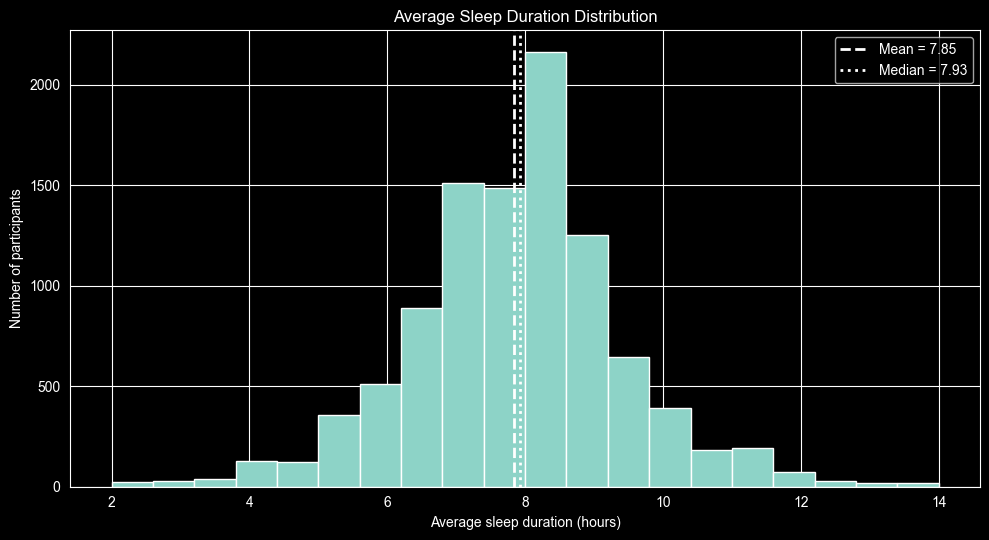

Graph saved to:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\average_sleep_duration_distribution.png


In [4]:
# ------------------------------------------------------------
# Graph average sleep duration distribution
# ------------------------------------------------------------

import matplotlib.pyplot as plt

# Select average sleep duration values
avg_sleep_h = sleep_duration_analysis["avg_sleep_h"].dropna()

plt.figure(figsize=(10, 5.5))

plt.hist(avg_sleep_h, bins=20)

plt.axvline(
    avg_sleep_h.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {avg_sleep_h.mean():.2f}"
)

plt.axvline(
    avg_sleep_h.median(),
    linestyle=":",
    linewidth=2,
    label=f"Median = {avg_sleep_h.median():.2f}"
)

plt.title("Average Sleep Duration Distribution")
plt.xlabel("Average sleep duration (hours)")
plt.ylabel("Number of participants")
plt.legend()
plt.tight_layout()

# Save the graph
sleep_duration_graph_path = GRAPH_DIR / "average_sleep_duration_distribution.png"
plt.savefig(sleep_duration_graph_path, dpi=300, bbox_inches="tight")

plt.show()

print("Graph saved to:")
print(sleep_duration_graph_path)

---

# 5. ✧ Checking Sleep Duration Outliers

The average sleep duration variable has a clear central range, but it also includes very low and very high values.

Before deciding the final installation range, we check whether any sleep duration values are statistical outliers.

We use the IQR method:

**IQR = Q3 - Q1**

Then we calculate:

**Lower boundary = Q1 - 1.5 × IQR**

**Upper boundary = Q3 + 1.5 × IQR**

This helps us see whether extremely short or extremely long sleep durations should be treated carefully when mapping the installation.


In [5]:
# ------------------------------------------------------------
# IQR outlier check for avg_sleep_h
# ------------------------------------------------------------

avg_sleep_h = sleep_duration_analysis["avg_sleep_h"].dropna()

# Calculate quartiles and IQR
sleep_q1 = avg_sleep_h.quantile(0.25)
sleep_q3 = avg_sleep_h.quantile(0.75)
sleep_iqr = sleep_q3 - sleep_q1

# Calculate outlier boundaries
sleep_lower_boundary = sleep_q1 - 1.5 * sleep_iqr
sleep_upper_boundary = sleep_q3 + 1.5 * sleep_iqr

print("Average sleep duration IQR outlier check")
print("----------------------------------------")
print("Q1:", round(sleep_q1, 2), "hours")
print("Q3:", round(sleep_q3, 2), "hours")
print("IQR:", round(sleep_iqr, 2), "hours")
print("Lower outlier boundary:", round(sleep_lower_boundary, 2), "hours")
print("Upper outlier boundary:", round(sleep_upper_boundary, 2), "hours")

# Identify outliers
sleep_outlier_mask = (
    (sleep_duration_analysis["avg_sleep_h"] < sleep_lower_boundary) |
    (sleep_duration_analysis["avg_sleep_h"] > sleep_upper_boundary)
)

sleep_duration_outliers = sleep_duration_analysis[sleep_outlier_mask].copy()
sleep_duration_clean = sleep_duration_analysis[~sleep_outlier_mask].copy()

removed_percentage = (
    len(sleep_duration_outliers) / len(sleep_duration_analysis)
) * 100

print("\nOutlier check summary")
print("---------------------")
print("Original participants:", len(sleep_duration_analysis))
print("Detected outlier participants:", len(sleep_duration_outliers))
print("Participants inside IQR range:", len(sleep_duration_clean))
print("Detected outlier percentage:", round(removed_percentage, 2), "%")

print("\nLowest detected outlier values:")
display(
    sleep_duration_outliers
    .sort_values("avg_sleep_h", ascending=True)
    .head(20)
)

print("\nHighest detected outlier values:")
display(
    sleep_duration_outliers
    .sort_values("avg_sleep_h", ascending=False)
    .head(20)
)

Average sleep duration IQR outlier check
----------------------------------------
Q1: 7.0 hours
Q3: 8.71 hours
IQR: 1.71 hours
Lower outlier boundary: 4.43 hours
Upper outlier boundary: 11.29 hours

Outlier check summary
---------------------
Original participants: 10069
Detected outlier participants: 426
Participants inside IQR range: 9643
Detected outlier percentage: 4.23 %

Lowest detected outlier values:


,SEQN,SLD012,SLD013,avg_sleep_h
500,110081.0,2.0,2.0,2.000000
9567,123899.0,2.0,2.0,2.000000
8586,122409.0,2.0,2.0,2.000000
7455,120666.0,2.0,2.0,2.000000
1227,111190.0,2.0,2.0,2.000000
1287,111272.0,2.0,2.0,2.000000
8413,122156.0,2.0,2.0,2.000000
7237,120348.0,2.0,2.0,2.000000
5676,117962.0,2.0,2.0,2.000000
6648,119450.0,2.0,2.0,2.000000



Highest detected outlier values:


,SEQN,SLD012,SLD013,avg_sleep_h
10166,124784.0,14.0,14.0,14.000000
9594,123941.0,14.0,14.0,14.000000
513,110100.0,14.0,14.0,14.000000
6673,119489.0,14.0,14.0,14.000000
2526,113168.0,14.0,14.0,14.000000
2811,113591.0,14.0,14.0,14.000000
5183,117180.0,14.0,14.0,14.000000
2428,113008.0,14.0,14.0,14.000000
3441,114547.0,14.0,14.0,14.000000
3051,113949.0,14.0,14.0,14.000000


---

# 6. ✧ Creating the Daytime Sleepiness Variable

Now we create the optional daytime sleepiness variable.

The NHANES variable is:

**SLQ120**

In this notebook, we rename it to:

**daytime_sleepiness**

This variable represents how often participants felt overly sleepy during the day.

It can be used as an optional tiredness or heaviness layer in the installation.

For example, higher daytime sleepiness could make the atmosphere feel heavier, slower, or more difficult to move through.


In [6]:
# ------------------------------------------------------------
# Create daytime_sleepiness variable
# ------------------------------------------------------------

sleepiness_columns = [
    "SEQN",
    "SLQ120"
]

# Check that needed columns exist
missing_columns = [
    column for column in sleepiness_columns
    if column not in sleep_df.columns
]

if missing_columns:
    print("Missing columns:")
    print(missing_columns)
else:
    print("All daytime sleepiness columns found!")

# Select needed columns
sleepiness_analysis = sleep_df[sleepiness_columns].copy()

# Rename variable for the project
sleepiness_analysis = sleepiness_analysis.rename(
    columns={
        "SLQ120": "daytime_sleepiness"
    }
)

# Convert to numeric
sleepiness_analysis["daytime_sleepiness"] = pd.to_numeric(
    sleepiness_analysis["daytime_sleepiness"],
    errors="coerce"
)

# Replace possible special missing codes with missing values
special_missing_codes = [7, 9, 77, 99, 7777, 9999]

sleepiness_analysis["daytime_sleepiness"] = sleepiness_analysis[
    "daytime_sleepiness"
].replace(
    special_missing_codes,
    pd.NA
)

# Keep only valid values
sleepiness_analysis = sleepiness_analysis[
    sleepiness_analysis["daytime_sleepiness"].notna()
].copy()

daytime_sleepiness = sleepiness_analysis["daytime_sleepiness"]

print("Daytime sleepiness variable created.")
print("Valid participants:", len(sleepiness_analysis))

print("\nDaytime sleepiness descriptive statistics")
print("-----------------------------------------")
print("Minimum:", round(daytime_sleepiness.min(), 2))
print("Maximum:", round(daytime_sleepiness.max(), 2))
print("Mean:", round(daytime_sleepiness.mean(), 2))
print("Median:", round(daytime_sleepiness.median(), 2))
print("Standard deviation:", round(daytime_sleepiness.std(), 2))

# Clean table for display
sleepiness_stats_table = pd.DataFrame({
    "Statistic": [
        "Count",
        "Minimum",
        "25th percentile",
        "Median",
        "Mean",
        "75th percentile",
        "Maximum",
        "Standard deviation"
    ],
    "Value": [
        f"{int(daytime_sleepiness.count())} participants",
        f"{daytime_sleepiness.min():.2f}",
        f"{daytime_sleepiness.quantile(0.25):.2f}",
        f"{daytime_sleepiness.median():.2f}",
        f"{daytime_sleepiness.mean():.2f}",
        f"{daytime_sleepiness.quantile(0.75):.2f}",
        f"{daytime_sleepiness.max():.2f}",
        f"{daytime_sleepiness.std():.2f}"
    ],
    "Simple meaning": [
        "Number of valid participants analyzed",
        "Lowest daytime sleepiness score",
        "25% of participants were at or below this value",
        "Middle daytime sleepiness score",
        "Average daytime sleepiness score",
        "75% of participants were at or below this value",
        "Highest daytime sleepiness score",
        "How spread out the daytime sleepiness values are"
    ]
})

display(sleepiness_stats_table)

print("\nFull numeric descriptive statistics:")
print(daytime_sleepiness.describe().to_string())

All daytime sleepiness columns found!
Daytime sleepiness variable created.
Valid participants: 10175

Daytime sleepiness descriptive statistics
-----------------------------------------
Minimum: 0.0
Maximum: 4.0
Mean: 1.75
Median: 2.0
Standard deviation: 1.17


,Statistic,Value,Simple meaning
0,Count,10175 participants,Number of valid participants analyzed
1,Minimum,0.00,Lowest daytime sleepiness score
2,25th percentile,1.00,25% of participants were at or below this value
3,Median,2.00,Middle daytime sleepiness score
4,Mean,1.75,Average daytime sleepiness score
5,75th percentile,3.00,75% of participants were at or below this value
6,Maximum,4.00,Highest daytime sleepiness score
7,Standard deviation,1.17,How spread out the daytime sleepiness values are



Full numeric descriptive statistics:
count     10175.0
unique        5.0
top           2.0
freq       3373.0


---

# 7. ✧ Graphing the Daytime Sleepiness Distribution

Now we create a distribution graph for the daytime_sleepiness variable.

The variable ranges from 0 to 4.

Because daytime_sleepiness is a questionnaire response scale, we use a bar chart.

This graph shows how many participants selected each daytime sleepiness score.


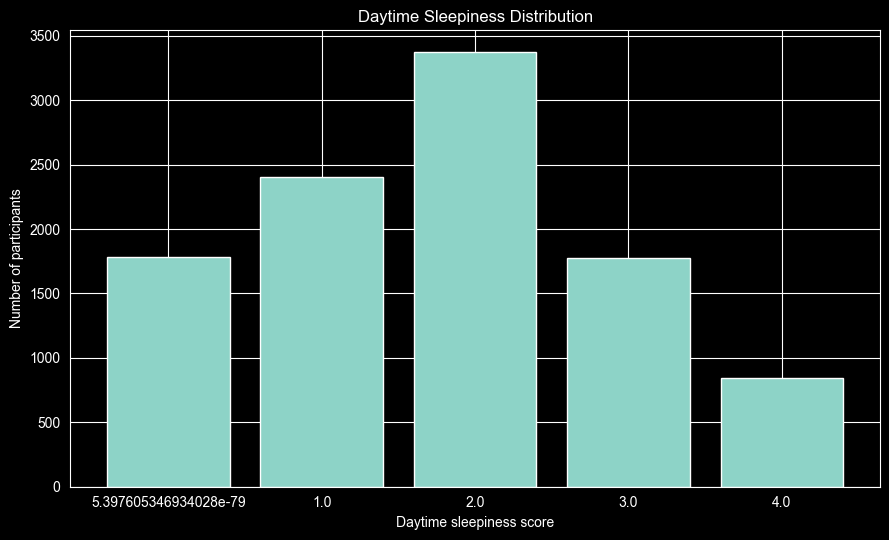

Graph saved to:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\daytime_sleepiness_distribution.png


,daytime_sleepiness,participant_count
0,0.0,1780
1,1.0,2407
2,2.0,3373
3,3.0,1775
4,4.0,840


In [7]:
# ------------------------------------------------------------
# Graph daytime_sleepiness distribution
# ------------------------------------------------------------

import matplotlib.pyplot as plt

# Count how many participants chose each sleepiness score
sleepiness_counts = (
    sleepiness_analysis["daytime_sleepiness"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 5.5))

plt.bar(
    sleepiness_counts.index.astype(str),
    sleepiness_counts.values
)

plt.title("Daytime Sleepiness Distribution")
plt.xlabel("Daytime sleepiness score")
plt.ylabel("Number of participants")
plt.tight_layout()

# Save the graph
sleepiness_graph_path = GRAPH_DIR / "daytime_sleepiness_distribution.png"
plt.savefig(sleepiness_graph_path, dpi=300, bbox_inches="tight")

plt.show()

print("Graph saved to:")
print(sleepiness_graph_path)

# Display the count table too
sleepiness_count_table = pd.DataFrame({
    "daytime_sleepiness": sleepiness_counts.index,
    "participant_count": sleepiness_counts.values
})

display(sleepiness_count_table)

---

# 8. ✧ Finding the StudentLife Sleep Quality Data

Now we move from NHANES sleep duration to StudentLife sleep quality.

The goal is to create:

**sleep_quality_problem**

This variable represents how problematic the participant’s sleep quality was.

Before creating the variable, we first search the StudentLife dataset folder for sleep-related files.

This helps us confirm the exact file and column names before calculating the sleep quality score.


In [8]:
# ------------------------------------------------------------
# Find possible StudentLife sleep files
# ------------------------------------------------------------

# Search from the whole StudentLife folder
search_root = STUDENTLIFE_DIR

# Collect all files
all_studentlife_files = list(search_root.rglob("*"))

# Keep only actual files
all_studentlife_files = [
    file for file in all_studentlife_files
    if file.is_file()
]

print("Total files found in StudentLife folder:", len(all_studentlife_files))

# Keywords that may identify sleep files
sleep_keywords = [
    "sleep",
    "Sleep"
]

sleep_matches = []

for file in all_studentlife_files:
    file_text = str(file).lower()

    if any(keyword.lower() in file_text for keyword in sleep_keywords):
        sleep_matches.append(file)

print("\nPossible sleep-related files:")
print("-----------------------------")

for file in sleep_matches:
    print(file)

# Make a cleaner table for viewing
sleep_file_match_table = pd.DataFrame({
    "file_path": [str(file) for file in sleep_matches]
})

display(sleep_file_match_table)

Total files found in StudentLife folder: 50

Possible sleep-related files:
-----------------------------
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\Activity.Rds
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\Administration's response.Rds
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\Behavior.Rds
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\Boston Bombing.Rds
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\Cancelled Classes.Rds
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\Class 2.Rds
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\Class.Rds
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\

,file_path
0,D:\Documentos\Sleep datasets\sleep_installatio...
1,D:\Documentos\Sleep datasets\sleep_installatio...
2,D:\Documentos\Sleep datasets\sleep_installatio...
3,D:\Documentos\Sleep datasets\sleep_installatio...
4,D:\Documentos\Sleep datasets\sleep_installatio...
5,D:\Documentos\Sleep datasets\sleep_installatio...
6,D:\Documentos\Sleep datasets\sleep_installatio...
7,D:\Documentos\Sleep datasets\sleep_installatio...
8,D:\Documentos\Sleep datasets\sleep_installatio...
9,D:\Documentos\Sleep datasets\sleep_installatio...


---

# 9. ✧ Inspecting StudentLife Sleep Quality Files

The file search found two sleep-related files that may be useful:

| File            | Possible use                                    |
| --------------- | ----------------------------------------------- |
| EMA/Sleep.Rds   | Daily or momentary sleep quality information    |
| survey/psqi.Rds | General sleep quality questionnaire information |

Before creating the final sleep_quality_problem variable, we inspect both files.

This helps us choose the clearest and most useful sleep quality variable for the installation.


In [9]:
# ------------------------------------------------------------
# Load and inspect StudentLife sleep quality files
# ------------------------------------------------------------

from pathlib import Path
import pandas as pd

# Re-create the project paths in case the notebook forgot them
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
STUDENTLIFE_DIR = DATA_DIR / "studentlife_rds" / "dataset_rds"
GRAPH_DIR = PROJECT_DIR / "Graphs"

GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print("Current folder:", CURRENT_DIR)
print("Project folder:", PROJECT_DIR)
print("Data folder:", DATA_DIR)
print("StudentLife folder:", STUDENTLIFE_DIR)
print("Graph folder:", GRAPH_DIR)

print("\nDoes StudentLife folder exist?")
print(STUDENTLIFE_DIR.exists())


# If pyreadr is not installed, install it once with:
# !pip install pyreadr

try:
    import pyreadr
    print("\npyreadr is ready.")
except ImportError:
    print("\npyreadr is not installed yet.")
    print("Run this in a new code cell, then run this cell again:")
    print("!pip install pyreadr")


def load_rds_file(file_path):
    result = pyreadr.read_r(str(file_path))

    # Most Rds files load with one unnamed object.
    # This takes the first object inside the file.
    data = list(result.values())[0]

    return data


# Main sleep-related files
sleep_ema_file = STUDENTLIFE_DIR / "EMA" / "Sleep.Rds"
psqi_file = STUDENTLIFE_DIR / "survey" / "psqi.Rds"

print("\nSleep EMA file exists:", sleep_ema_file.exists(), "-", sleep_ema_file)
print("PSQI survey file exists:", psqi_file.exists(), "-", psqi_file)

if not sleep_ema_file.exists():
    raise FileNotFoundError(f"Could not find Sleep.Rds at: {sleep_ema_file}")

if not psqi_file.exists():
    raise FileNotFoundError(f"Could not find psqi.Rds at: {psqi_file}")


# Load files
sleep_ema_df = load_rds_file(sleep_ema_file)
psqi_df = load_rds_file(psqi_file)


print("\n" + "="*70)
print("EMA Sleep.Rds")
print("Shape:", sleep_ema_df.shape)
print("Columns:")
print(sleep_ema_df.columns.tolist())

print("\nFirst 20 rows:")
display(sleep_ema_df.head(20))

print("\nDescriptive statistics:")
display(sleep_ema_df.describe(include="all"))


print("\n" + "="*70)
print("Survey psqi.Rds")
print("Shape:", psqi_df.shape)
print("Columns:")
print(psqi_df.columns.tolist())

print("\nFirst 20 rows:")
display(psqi_df.head(20))

print("\nDescriptive statistics:")
display(psqi_df.describe(include="all"))

Current folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Notebooks
Project folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis
Data folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data
StudentLife folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds
Graph folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs

Does StudentLife folder exist?
True

pyreadr is ready.

Sleep EMA file exists: True - D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\Sleep.Rds
PSQI survey file exists: True - D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\survey\psqi.Rds

EMA Sleep.Rds
Shape: (1644, 6)
Columns:
['hour', 'location', 'rate', 'timestamp', 'social', 'uid']

First 20 rows:


,hour,location,rate,timestamp,social,uid
0,NaN,NaN,NaN,1.364115e+09,NaN,0
1,NaN,NaN,NaN,1.364115e+09,NaN,0
2,NaN,NaN,NaN,1.364114e+09,NaN,0
3,NaN,NaN,NaN,1.364115e+09,NaN,0
4,NaN,NaN,NaN,1.364114e+09,NaN,0
5,NaN,NaN,NaN,1.364115e+09,NaN,0
6,NaN,NaN,NaN,1.364115e+09,NaN,0
7,NaN,NaN,NaN,1.364148e+09,NaN,0
8,8.0,"43.70692415,-72.2873929",1.0,1.364238e+09,1.0,0
9,5.0,"43.70708859,-72.28753397",3.0,1.365010e+09,2.0,0



Descriptive statistics:


,hour,location,rate,timestamp,social,uid
count,1390.000000,1388,1390.000000,1.644000e+03,1390.000000,1644
unique,NaN,1193,NaN,NaN,NaN,49
top,NaN,Unknown,NaN,NaN,NaN,59
freq,NaN,103,NaN,NaN,NaN,73
mean,7.225180,NaN,1.907194,1.366031e+09,1.429496,NaN
std,2.403878,NaN,0.851471,1.658629e+06,0.788045,NaN
min,0.000000,NaN,1.000000,1.364114e+09,1.000000,NaN
25%,6.000000,NaN,1.000000,1.364748e+09,1.000000,NaN
50%,7.000000,NaN,2.000000,1.365615e+09,1.000000,NaN
75%,8.000000,NaN,2.000000,1.367084e+09,2.000000,NaN



Survey psqi.Rds
Shape: (84, 21)
Columns:
['uid', 'type', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19']

First 20 rows:


,uid,type,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,...,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19
0,0,pre,2:00 AM,10 mins,7:00 AM,6 hours,Not during the past month,Three or a more times week,Three or a more times week,Not during the past month,...,Not during the past month,Not during the past month,Less than once week,Not during the past month,Once or a twice week,headaches,Not during the past month,Not during the past month,Once or a twice week,Fairly bad
1,1,pre,1AM,20,11AM,10-Sep,Not during the past month,Three or a more times week,Not during the past month,Not during the past month,...,Once or a twice week,Once or a twice week,Less than once week,Not during the past month,Not during the past month,NaN,Less than once week,Once or a twice week,Once or a twice week,Very good
2,2,pre,around 1 am,"I fall asleep really quickly, maybe 5-10minutes",about 9am,about 7-8hours,Not during the past month,Not during the past month,Not during the past month,Not during the past month,...,Less than once week,Not during the past month,Not during the past month,Not during the past month,Not during the past month,NaN,Not during the past month,Once or a twice week,Once or a twice week,Fairly good
3,3,pre,1am,10min,8:30am,7hours,Not during the past month,Not during the past month,Not during the past month,Not during the past month,...,Not during the past month,Not during the past month,Less than once week,Not during the past month,Not during the past month,NaN,Not during the past month,Less than once week,Less than once week,Fairly good
4,4,pre,11:30,10,6:00,6:00,Not during the past month,Less than once week,Less than once week,Not during the past month,...,Less than once week,Not during the past month,Not during the past month,Not during the past month,Not during the past month,NaN,Not during the past month,Not during the past month,Once or a twice week,Fairly good
5,5,pre,11:30pm,15,8:00am,8,Less than once week,Less than once week,Less than once week,Not during the past month,...,Not during the past month,Once or a twice week,Not during the past month,Not during the past month,Not during the past month,NaN,Not during the past month,Less than once week,Not during the past month,Very good
6,7,pre,Between 12a and 2a,20 minutes,between 9a and 11a,8,Once or a twice week,Not during the past month,Not during the past month,Not during the past month,...,Not during the past month,Not during the past month,Less than once week,Less than once week,Not during the past month,NaN,Not during the past month,Once or a twice week,Once or a twice week,Fairly good
7,8,pre,1:00 AM,15 minutes,9:00 AM,7 Hours,Once or a twice week,Less than once week,Not during the past month,Not during the past month,...,Not during the past month,Less than once week,Not during the past month,Not during the past month,Not during the past month,NaN,Not during the past month,Not during the past month,Less than once week,Fairly good
8,9,pre,12:00,10,8:30,7.5,Not during the past month,Not during the past month,Once or a twice week,Not during the past month,...,Not during the past month,Not during the past month,Not during the past month,Not during the past month,Not during the past month,NaN,Not during the past month,Not during the past month,Three or a more times week,Very good
9,10,pre,12-1 AM,30,8:10 AM,8-Jul,Three or a more times week,Three or a more times week,Not during the past month,Not during the past month,...,Not during the past month,Not during the past month,Once or a twice week,Not during the past month,Once or a twice week,Trying to solve coding problems while in bed (...,Not during the past month,Less than once week,Less than once week,Fairly good



Descriptive statistics:


,uid,type,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,...,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19
count,84,84,83,83,83,83,81,82,81,81,...,81,81,81,81,70,11,83,83,82,83
unique,46,2,55,45,50,42,4,4,4,3,...,4,3,4,4,4,11,4,4,4,4
top,0,pre,2:00 AM,10,8:00,7,Not during the past month,Not during the past month,Not during the past month,Not during the past month,...,Not during the past month,Not during the past month,Not during the past month,Not during the past month,Not during the past month,Class work or all-nighters,Not during the past month,Not during the past month,Once or a twice week,Fairly good
freq,2,46,8,13,5,13,35,35,40,72,...,51,50,46,63,58,1,69,31,25,51


---

# 10. ✧ Creating the Sleep Quality Problem Variable

Now we create the sleep quality bridge variable.

The StudentLife EMA Sleep file contains a variable called:

**rate**

This variable ranges from 1 to 4.

For the installation, we convert this into:

**sleep_quality_problem**

The transformation is:

**sleep_quality_problem = rate - 1**

This creates a 0–3 sleep quality problem score.

| sleep_quality_problem | Meaning                        |
| --------------------- | ------------------------------ |
| 0                     | Lowest sleep quality problem   |
| 1                     | Mild sleep quality problem     |
| 2                     | Moderate sleep quality problem |
| 3                     | Highest sleep quality problem  |

This variable is important because it can be combined with sleep duration to create the final sleep_score.


In [10]:
# ------------------------------------------------------------
# Create sleep_quality_problem variable
# ------------------------------------------------------------

sleep_quality_analysis = sleep_ema_df[
    [
        "uid",
        "timestamp",
        "rate"
    ]
].copy()

# Convert rate to numeric
sleep_quality_analysis["rate"] = pd.to_numeric(
    sleep_quality_analysis["rate"],
    errors="coerce"
)

print("Missing values before keeping valid sleep quality cases:")
display(sleep_quality_analysis["rate"].isna().sum())

# Keep only valid rate values from 1 to 4
sleep_quality_analysis = sleep_quality_analysis[
    sleep_quality_analysis["rate"].notna() &
    (sleep_quality_analysis["rate"] >= 1) &
    (sleep_quality_analysis["rate"] <= 4)
].copy()

# Convert 1–4 rating into 0–3 problem score
sleep_quality_analysis["sleep_quality_problem"] = (
    sleep_quality_analysis["rate"] - 1
)

sleep_quality_problem = sleep_quality_analysis["sleep_quality_problem"]

print("Sleep quality problem variable created.")
print("Valid observations:", len(sleep_quality_analysis))

print("\nSleep quality problem descriptive statistics")
print("--------------------------------------------")
print("Minimum:", round(sleep_quality_problem.min(), 2))
print("Maximum:", round(sleep_quality_problem.max(), 2))
print("Mean:", round(sleep_quality_problem.mean(), 2))
print("Median:", round(sleep_quality_problem.median(), 2))
print("Standard deviation:", round(sleep_quality_problem.std(), 2))

# Clean table for display
sleep_quality_stats_table = pd.DataFrame({
    "Statistic": [
        "Count",
        "Minimum",
        "25th percentile",
        "Median",
        "Mean",
        "75th percentile",
        "Maximum",
        "Standard deviation"
    ],
    "Value": [
        f"{int(sleep_quality_problem.count())} observations",
        f"{sleep_quality_problem.min():.2f}",
        f"{sleep_quality_problem.quantile(0.25):.2f}",
        f"{sleep_quality_problem.median():.2f}",
        f"{sleep_quality_problem.mean():.2f}",
        f"{sleep_quality_problem.quantile(0.75):.2f}",
        f"{sleep_quality_problem.max():.2f}",
        f"{sleep_quality_problem.std():.2f}"
    ],
    "Simple meaning": [
        "Number of valid sleep quality observations analyzed",
        "Lowest sleep quality problem score",
        "25% of observations were at or below this value",
        "Middle sleep quality problem score",
        "Average sleep quality problem score",
        "75% of observations were at or below this value",
        "Highest sleep quality problem score",
        "How spread out the sleep quality problem values are"
    ]
})

display(sleep_quality_stats_table)

print("\nFull numeric descriptive statistics:")
print(sleep_quality_problem.describe().to_string())

# Display value counts too, because this is a 0–3 scale
print("\nSleep quality problem value counts:")
display(
    sleep_quality_problem
    .value_counts()
    .sort_index()
)

Missing values before keeping valid sleep quality cases:


np.int64(254)

Sleep quality problem variable created.
Valid observations: 1390

Sleep quality problem descriptive statistics
--------------------------------------------
Minimum: 0.0
Maximum: 3.0
Mean: 0.91
Median: 1.0
Standard deviation: 0.85


,Statistic,Value,Simple meaning
0,Count,1390 observations,Number of valid sleep quality observations ana...
1,Minimum,0.00,Lowest sleep quality problem score
2,25th percentile,0.00,25% of observations were at or below this value
3,Median,1.00,Middle sleep quality problem score
4,Mean,0.91,Average sleep quality problem score
5,75th percentile,1.00,75% of observations were at or below this value
6,Maximum,3.00,Highest sleep quality problem score
7,Standard deviation,0.85,How spread out the sleep quality problem value...



Full numeric descriptive statistics:
count    1390.000000
mean        0.907194
std         0.851471
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         3.000000

Sleep quality problem value counts:


sleep_quality_problem
0.0    505
1.0    578
2.0    238
3.0     69
Name: count, dtype: int64

---

# 11. ✧ Graphing the Sleep Quality Problem Distribution

Now we create a distribution graph for the sleep_quality_problem variable.

The variable ranges from 0 to 3.

Because sleep_quality_problem is a rating scale, we use a bar chart.

This graph shows how many observations fall into each sleep quality problem score.


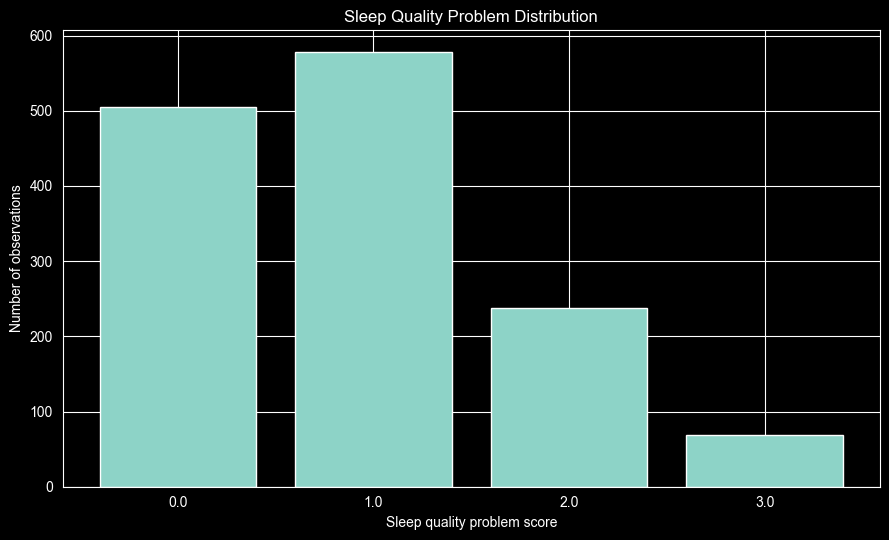

Graph saved to:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\sleep_quality_problem_distribution.png


,sleep_quality_problem,observation_count
0,0.0,505
1,1.0,578
2,2.0,238
3,3.0,69


In [11]:
# ------------------------------------------------------------
# Graph sleep_quality_problem distribution
# ------------------------------------------------------------

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Re-create GRAPH_DIR if the notebook forgot it
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

GRAPH_DIR = PROJECT_DIR / "Graphs"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

# Count how many observations fall into each sleep quality problem score
sleep_quality_counts = (
    sleep_quality_analysis["sleep_quality_problem"]
    .value_counts()
    .sort_index()
)

# Create the graph
plt.figure(figsize=(9, 5.5))

plt.bar(
    sleep_quality_counts.index.astype(str),
    sleep_quality_counts.values
)

plt.title("Sleep Quality Problem Distribution")
plt.xlabel("Sleep quality problem score")
plt.ylabel("Number of observations")
plt.tight_layout()

# Save the graph
sleep_quality_graph_path = GRAPH_DIR / "sleep_quality_problem_distribution.png"
plt.savefig(sleep_quality_graph_path, dpi=300, bbox_inches="tight")

plt.show()

print("Graph saved to:")
print(sleep_quality_graph_path)

# Display the count table too
sleep_quality_count_table = pd.DataFrame({
    "sleep_quality_problem": sleep_quality_counts.index,
    "observation_count": sleep_quality_counts.values
})

display(sleep_quality_count_table)

## 12. ✧ Creating the Duration Problem Score

Now we convert average sleep duration into a duration problem score.

This mapping is based on the sleep duration component of the Pittsburgh Sleep Quality Index, or PSQI.

The score ranges from 0 to 3.

A lower score means a healthier sleep duration.

A higher score means a stronger sleep duration problem.

In [13]:
# ------------------------------------------------------------
# Create duration_problem from NHANES average sleep duration
# ------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd

# Re-create paths in case the notebook forgot them
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
NHANES_DIR = DATA_DIR / "nhanes"
GRAPH_DIR = PROJECT_DIR / "Graphs"

GRAPH_DIR.mkdir(parents=True, exist_ok=True)

# Load NHANES sleep questionnaire file again
slq_path = NHANES_DIR / "P_SLQ.XPT"

sleep_raw = pd.read_sas(slq_path, format="xport")

# Keep only the columns needed for average sleep duration
duration_problem_analysis = sleep_raw[["SEQN", "SLD012", "SLD013"]].copy()

# Make sure sleep columns are numeric
duration_problem_analysis["SLD012"] = pd.to_numeric(
    duration_problem_analysis["SLD012"],
    errors="coerce"
)

duration_problem_analysis["SLD013"] = pd.to_numeric(
    duration_problem_analysis["SLD013"],
    errors="coerce"
)

# Calculate average sleep duration
duration_problem_analysis["avg_sleep_h"] = (
    (5 * duration_problem_analysis["SLD012"] + 2 * duration_problem_analysis["SLD013"]) / 7
)

# Remove rows without valid average sleep duration
duration_problem_analysis = duration_problem_analysis.dropna(
    subset=["avg_sleep_h"]
).copy()

# Create duration problem score
duration_problem_analysis["duration_problem"] = np.select(
    [
        duration_problem_analysis["avg_sleep_h"] > 7,
        (duration_problem_analysis["avg_sleep_h"] >= 6) & (duration_problem_analysis["avg_sleep_h"] <= 7),
        (duration_problem_analysis["avg_sleep_h"] >= 5) & (duration_problem_analysis["avg_sleep_h"] < 6),
        duration_problem_analysis["avg_sleep_h"] < 5,
    ],
    [
        0,
        1,
        2,
        3,
    ],
    default=np.nan
)

# Count how many participants fall into each score
duration_problem_counts = (
    duration_problem_analysis["duration_problem"]
    .value_counts()
    .sort_index()
)

# Create a simple summary table
duration_problem_table = pd.DataFrame({
    "duration_problem": duration_problem_counts.index.astype(int),
    "count": duration_problem_counts.values,
})

duration_problem_table["percentage"] = (
    duration_problem_table["count"] / duration_problem_table["count"].sum() * 100
).round(2)

duration_problem_table

,duration_problem,count,percentage
0,0,7144,70.95
1,1,2056,20.42
2,2,524,5.20
3,3,345,3.43


## 13. ✧ Graphing the Duration Problem Distribution

Now we create a distribution graph for the duration_problem variable.

The variable ranges from 0 to 3.

Because duration_problem is a bounded score, we use a bar chart.

This graph shows how many participants fall into each sleep duration problem category.

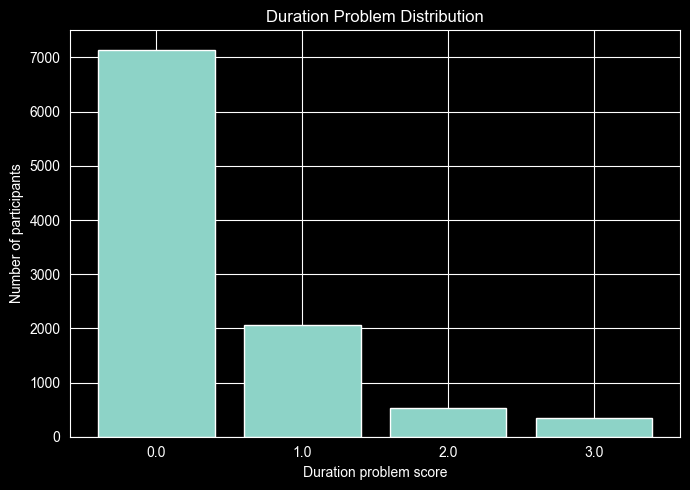

Graph saved to: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\duration_problem_distribution.png


In [14]:
# ------------------------------------------------------------
# Graph duration_problem distribution
# ------------------------------------------------------------

from pathlib import Path
import matplotlib.pyplot as plt

# Re-create GRAPH_DIR if the notebook forgot it
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

GRAPH_DIR = PROJECT_DIR / "Graphs"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

# Count how many participants fall into each duration problem score
duration_problem_counts = (
    duration_problem_analysis["duration_problem"]
    .value_counts()
    .sort_index()
)

# Create the graph
plt.figure(figsize=(7, 5))

plt.bar(
    duration_problem_counts.index.astype(str),
    duration_problem_counts.values
)

plt.title("Duration Problem Distribution")
plt.xlabel("Duration problem score")
plt.ylabel("Number of participants")
plt.tight_layout()

# Save the graph
duration_problem_graph_path = GRAPH_DIR / "duration_problem_distribution.png"
plt.savefig(duration_problem_graph_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Graph saved to: {duration_problem_graph_path}")

## 14. ✧ Creating the Sleep Score Mapping Table

Now we create the final sleep_score formula.

The sleep_score combines two bridge variables:

duration_problem
sleep_quality_problem

Both variables range from 0 to 3.

Together, they create a sleep_problem_score from 0 to 6.

This is then converted into a 0–100 installation score.

A higher sleep_score means a better sleep condition.

A lower sleep_score means a worse sleep condition.

Important: this is a reduced PSQI-inspired installation score, not the full clinical PSQI score.

In [15]:
# ------------------------------------------------------------
# Create sleep_score mapping table
# ------------------------------------------------------------

import pandas as pd

# Create all possible combinations of duration and quality problem scores
sleep_score_rows = []

for duration_problem in range(0, 4):
    for sleep_quality_problem in range(0, 4):
        sleep_problem_score = duration_problem + sleep_quality_problem

        sleep_score = 100 * (1 - sleep_problem_score / 6)

        sleep_score_rows.append({
            "duration_problem": duration_problem,
            "sleep_quality_problem": sleep_quality_problem,
            "sleep_problem_score": sleep_problem_score,
            "sleep_score": round(sleep_score, 2),
        })

# Create table
sleep_score_mapping_table = pd.DataFrame(sleep_score_rows)

# Show the table
sleep_score_mapping_table

,duration_problem,sleep_quality_problem,sleep_problem_score,sleep_score
0,0,0,0,100.00
1,0,1,1,83.33
2,0,2,2,66.67
3,0,3,3,50.00
4,1,0,1,83.33
5,1,1,2,66.67
6,1,2,3,50.00
7,1,3,4,33.33
8,2,0,2,66.67
9,2,1,3,50.00


## 15. ✧ Creating the Final Sleep Score Function

Now we turn the sleep_score formula into a reusable function.

This function can later be used in the installation.

The function takes two inputs:

duration_problem
sleep_quality_problem

Both inputs range from 0 to 3.

The function first calculates the total sleep_problem_score.

Then it converts this problem score into a 0–100 sleep_score.

A higher sleep_score means a better sleep condition.

A lower sleep_score means a worse sleep condition.

The score is kept as a continuous 0–100 value, because the installation can use the exact number to control the sleep meter and atmosphere.

In [16]:
# ------------------------------------------------------------
# Create reusable sleep_score function
# ------------------------------------------------------------

def calculate_sleep_score(duration_problem, sleep_quality_problem):
    """
    Calculate the reduced PSQI-inspired installation sleep score.

    Parameters
    ----------
    duration_problem : int or float
        Sleep duration problem score from 0 to 3.

    sleep_quality_problem : int or float
        Sleep quality problem score from 0 to 3.

    Returns
    -------
    float
        Sleep score from 0 to 100.
        Higher values mean better sleep condition.
    """

    # Combine the two problem scores
    sleep_problem_score = duration_problem + sleep_quality_problem

    # Convert the problem score into a 0-100 sleep score
    sleep_score = 100 * (1 - sleep_problem_score / 6)

    # Keep the score inside the 0-100 range
    sleep_score = max(0, min(100, sleep_score))

    return round(sleep_score, 2)


# Test the function with a few example cases
example_sleep_scores = pd.DataFrame({
    "duration_problem": [0, 1, 2, 3],
    "sleep_quality_problem": [0, 1, 2, 3],
})

example_sleep_scores["sleep_score"] = example_sleep_scores.apply(
    lambda row: calculate_sleep_score(
        row["duration_problem"],
        row["sleep_quality_problem"]
    ),
    axis=1
)

example_sleep_scores

,duration_problem,sleep_quality_problem,sleep_score
0,0,0,100.00
1,1,1,66.67
2,2,2,33.33
3,3,3,0.00


## 16. ✧ Sleep Score Mapping Table

Now we create a document-friendly table for the final sleep_score.

This table shows every possible combination of:

duration_problem
sleep_quality_problem

The final sleep_score is kept as a 0–100 score.

This means the installation can use the exact value instead of only using broad categories.

In [17]:
# ------------------------------------------------------------
# Create document-friendly sleep_score mapping table
# ------------------------------------------------------------

import pandas as pd

# Create all possible combinations again
sleep_score_rows = []

for duration_problem in range(0, 4):
    for sleep_quality_problem in range(0, 4):
        sleep_problem_score = duration_problem + sleep_quality_problem
        sleep_score = 100 * (1 - sleep_problem_score / 6)

        sleep_score_rows.append({
            "duration_problem": duration_problem,
            "sleep_quality_problem": sleep_quality_problem,
            "sleep_problem_score": sleep_problem_score,
            "sleep_score": round(sleep_score, 2),
        })

# Create table
sleep_score_document_table = pd.DataFrame(sleep_score_rows)

# Show all rows in the notebook output
pd.set_option("display.max_rows", None)

sleep_score_document_table

,duration_problem,sleep_quality_problem,sleep_problem_score,sleep_score
0,0,0,0,100.00
1,0,1,1,83.33
2,0,2,2,66.67
3,0,3,3,50.00
4,1,0,1,83.33
5,1,1,2,66.67
6,1,2,3,50.00
7,1,3,4,33.33
8,2,0,2,66.67
9,2,1,3,50.00
